## Import Module's 

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.preprocessing import LabelEncoder

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv(r"C:\Users\HP\Documents\NeuroNexus\tested.csv")
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


## Data Preprocessing - Analysis 

In [3]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
dff = df[['Sex','Age','Ticket','Pclass','Fare','Survived']]

In [6]:
le_sex = LabelEncoder()
le_ticket = LabelEncoder()

dff['Sex'] = le_sex.fit_transform(dff['Sex'])
dff['Ticket'] = le_ticket.fit_transform(dff['Ticket'])

C:\Users\HP\AppData\Local\Temp\ipykernel_7620\2129008502.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['Sex'] = le_sex.fit_transform(dff['Sex'])
C:\Users\HP\AppData\Local\Temp\ipykernel_7620\2129008502.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['Ticket'] = le_ticket.fit_transform(dff['Ticket'])


In [7]:
knn = KNNImputer(n_neighbors = 5)
dff = knn.fit_transform(dff)

In [8]:
dff = pd.DataFrame(dff, columns=['Sex', 'Age', 'Ticket', 'Pclass', 'Fare', 'Survived'])

In [9]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sex       418 non-null    float64
 1   Age       418 non-null    float64
 2   Ticket    418 non-null    float64
 3   Pclass    418 non-null    float64
 4   Fare      418 non-null    float64
 5   Survived  418 non-null    float64
dtypes: float64(6)
memory usage: 19.7 KB


In [10]:
# for column in dff:
#     print(column)
#     print(dff[column].unique())
#     print(dff[column].unique())

## Plotting Graphs

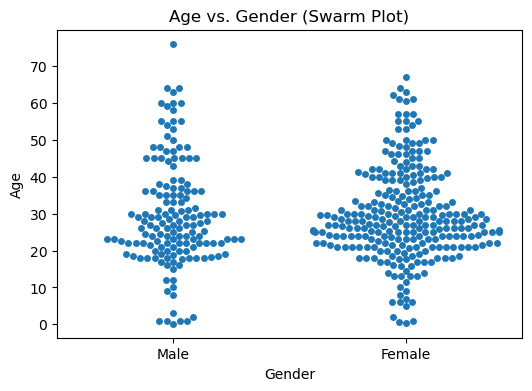

In [11]:
plt.figure(figsize=(6, 4))
sns.swarmplot(x='Sex', y='Age', data=dff)
plt.xticks([0, 1], ['Male', 'Female'])
plt.title("Age vs. Gender (Swarm Plot)")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.show()


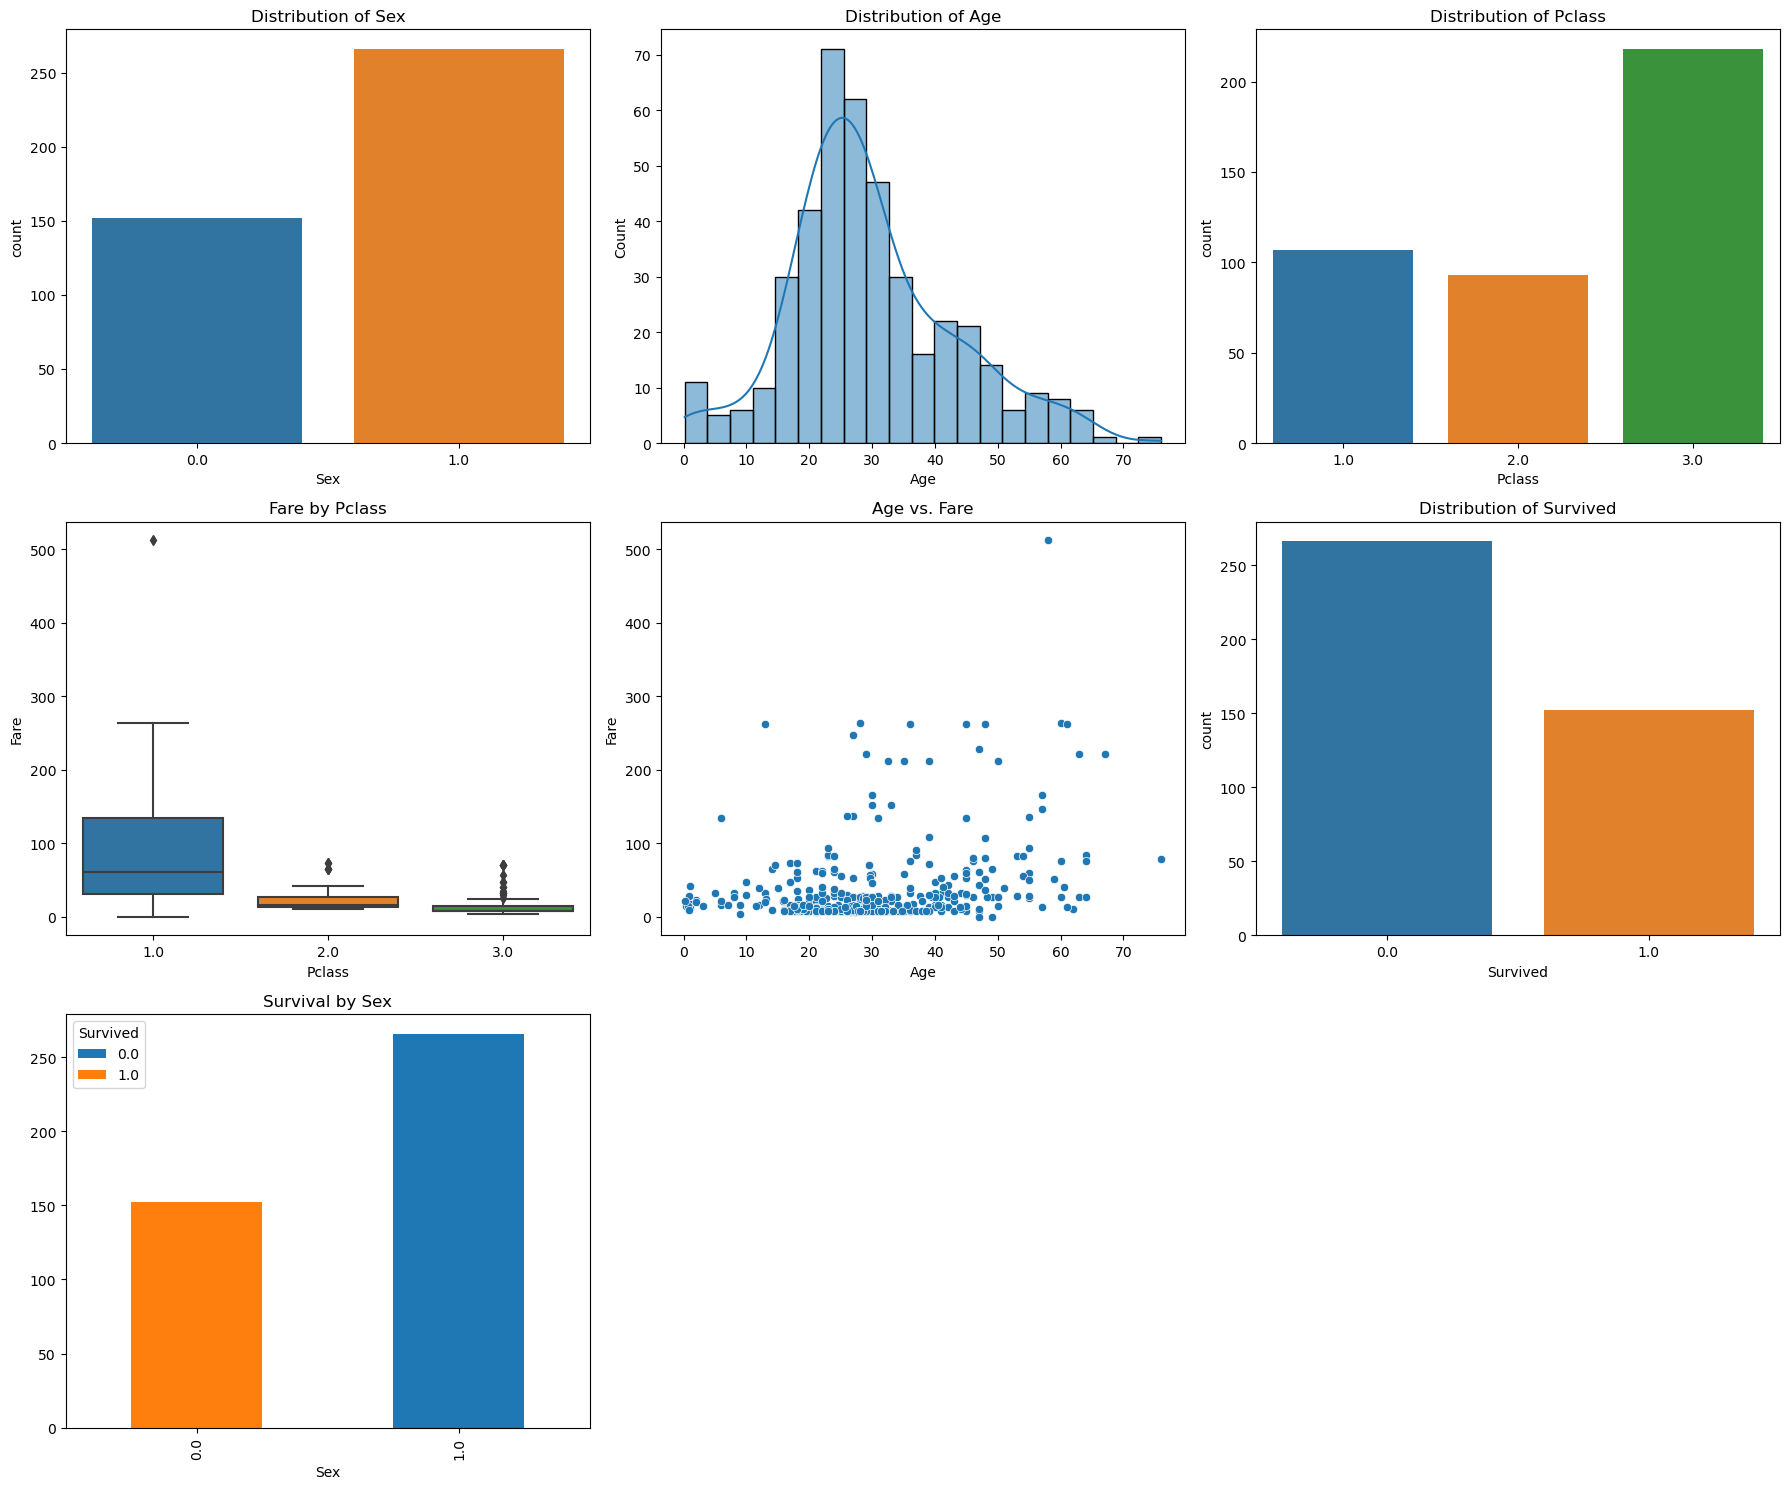

In [12]:
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# 1. Count Plot of `Sex`
sns.countplot(data=dff, x='Sex', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sex')

# 2. Histogram of `Age`
sns.histplot(data=dff, x='Age', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Age')

# 3. Count Plot of `Pclass`
sns.countplot(data=dff, x='Pclass', ax=axes[0, 2])
axes[0, 2].set_title('Distribution of Pclass')

# 4. Box Plot of `Fare` by `Pclass`
sns.boxplot(data=dff, x='Pclass', y='Fare', ax=axes[1, 0])
axes[1, 0].set_title('Fare by Pclass')

# 5. Scatter Plot of `Age` vs. `Fare`
sns.scatterplot(data=dff, x='Age', y='Fare', ax=axes[1, 1])
axes[1, 1].set_title('Age vs. Fare')

# 6. Count Plot of `Survived`
sns.countplot(data=dff, x='Survived', ax=axes[1, 2])
axes[1, 2].set_title('Distribution of Survived')

# 7. Stacked Bar Chart of `Sex` by `Survived`
# Group the data by 'Sex' and 'Survived' and count the occurrences
grouped_data = dff.groupby(['Sex', 'Survived']).size().unstack()
grouped_data.plot(kind='bar', stacked=True, ax=axes[2, 0])
axes[2, 0].set_title('Survival by Sex')

# Remove the empty subplots
fig.delaxes(axes[2, 1])
fig.delaxes(axes[2, 2])

# Adjust layout
plt.tight_layout()
plt.show()

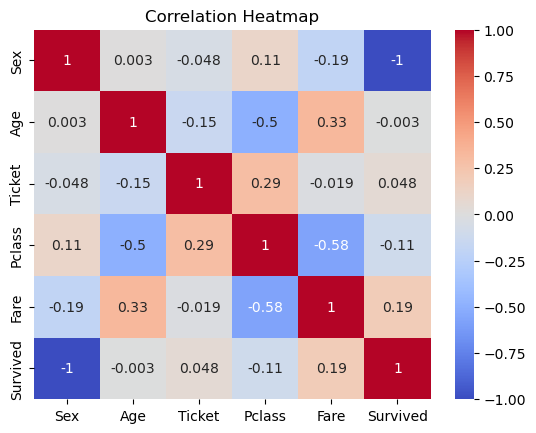

In [13]:
# Plot the correlation heatmap
corr_matrix = dff.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Implementing ML model

In [15]:
x = dff.drop(columns=['Survived'])
y = dff['Survived']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [16]:
rfc = RandomForestClassifier(n_estimators=60, random_state=20)
rfc.fit(x_train,y_train)

RandomForestClassifier(n_estimators=60, random_state=20)

In [17]:
rfc.score(x_test,y_test)

1.0

In [18]:
y_pred = rfc.predict(x)
report = classification_report(y,y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       266
         1.0       1.00      1.00      1.00       152

    accuracy                           1.00       418
   macro avg       1.00      1.00      1.00       418
weighted avg       1.00      1.00      1.00       418

